# Project Report: Improving Applicant Engagement through A/B Testing

**Author:** [Your Name]
**Date:** [Date]


## Executive Summary

**Problem:** A critical stage in our applicant journey—the admissions quiz—experiences a significant 25% drop-off rate. This represents a substantial loss of potentially qualified candidates before they fully engage with our platform.

**Action:** To address this, we designed and executed a controlled A/B test to determine if a simple, low-cost intervention—a targeted reminder email—could increase the quiz completion rate. We segmented applicants who did not immediately complete the quiz into a control group (no email) and a treatment group (received a reminder email).

**Outcome:** The 10-day experiment, which involved over 400 participants, revealed that the reminder email did not produce a statistically significant increase in quiz completion. While the treatment group showed a slightly higher completion rate, the difference was not substantial enough to be attributed to the email itself, falling within the realm of random chance.

**Recommendation:** Based on this data-driven finding, we recommend **not** proceeding with a full-scale rollout of this specific email reminder campaign. This prevents the allocation of resources to an ineffective strategy. Instead, we advise focusing future efforts on understanding the root causes of the initial drop-off, such as user experience friction or quiz design, and testing alternative, potentially higher-impact interventions.

## 1. Introduction and Problem Statement

The initial stages of the applicant funnel are crucial for converting interest into engagement. Our data indicates that while many prospective candidates create an account, a notable portion—approximately one-quarter—do not proceed to complete the mandatory admissions quiz. This project's primary objective is to test a potential solution to mitigate this drop-off.

We will employ an A/B testing framework to evaluate the effectiveness of a reminder email. This leads to the formulation of our core hypotheses:

- **Null Hypothesis ($H_0$):** Sending a reminder email to applicants who have not completed the admissions quiz has no effect on the quiz completion rate.

- **Alternative Hypothesis ($H_a$):** Sending a reminder email to applicants who have not completed the admissions quiz increases the quiz completion rate.

This report details the exploratory data analysis, experimental design, statistical testing, and final recommendations derived from this initiative.

### Initial Setup and Imports
We begin by importing the necessary Python libraries for data manipulation, analysis, and visualization.

In [2]:
import math
import random
from pprint import PrettyPrinter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import scipy
from country_converter import CountryConverter
from pymongo import MongoClient
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.power import GofChisquarePower

## 2. Data Overview and Exploratory Analysis

The applicant data is stored in a MongoDB database. Our first step is to establish a connection and explore the composition of our applicant pool to gain context before designing the experiment.

### Connecting to the Database
We connect to our local MongoDB instance and access the `ds-applicants` collection within the `wqu-abtest` database.

In [6]:
pp = PrettyPrinter(indent=2)
client = MongoClient(host='localhost', port=27017)
db = client['wqu-abtest']
ds_app = db["ds-applicants"]

print(f"Successfully connected to the '{ds_app.name}' collection.")

Successfully connected to the 'ds-applicants' collection.


A single document provides a rich set of information about each applicant, including personal, demographic, and application-specific data.

In [7]:
# Examine a sample document to understand the data structure
sample_doc = ds_app.find_one({})
pp.pprint(sample_doc)

{ '_id': ObjectId('66a7ae9a8c8bbff7ce5e4d4c'),
  'admissionsQuiz': 'incomplete',
  'birthday': datetime.datetime(1998, 4, 29, 0, 0),
  'countryISO2': 'GB',
  'createdAt': datetime.datetime(2022, 5, 13, 15, 2, 44),
  'email': 'terry.hassler28@yahow.com',
  'firstName': 'Terry',
  'gender': 'male',
  'highestDegreeEarned': "Bachelor's degree",
  'lastName': 'Hassler'}


### Applicant Nationality
To understand the geographic diversity of our applicants, we aggregate the data by country. The country codes are then converted to full names for better readability and visualization.

In [8]:
# Aggregate by country and count applicants
result = ds_app.aggregate([
    {
        "$group": {
            "_id": "$countryISO2", 
            "count": {"$count": {}}
        }
    }
])

# Convert to DataFrame and enrich with country names
df_nationality = pd.DataFrame(result).rename({"_id": "country_iso2"}, axis="columns").sort_values("count")

cc = CountryConverter()
df_nationality["country_name"] = cc.convert(df_nationality['country_iso2'], to="short_name")
df_nationality["country_iso3"] = cc.convert(df_nationality["country_iso2"], to="iso3")
df_nationality["count_pct"] = (df_nationality["count"] / df_nationality['count'].sum()) * 100

df_nationality.tail()

,country_iso2,count,country_name,country_iso3,count_pct
17,BD,254,Bangladesh,BGD,5.054726
43,KE,304,Kenya,KEN,6.049751
73,IN,511,India,IND,10.169154
51,PK,568,Pakistan,PAK,11.303483
57,NG,1238,Nigeria,NGA,24.636816


A choropleth map provides an intuitive global overview of applicant distribution.

In [9]:
# Create choropleth map
fig_nat = px.choropleth(
    data_frame=df_nationality,
    locations="country_iso3",
    color="count_pct",
    projection="natural earth",
    color_continuous_scale=px.colors.sequential.Oranges,
    title="DS Applicants by Nationality (% of Total)"
)
fig_nat.show()

### Applicant Age Distribution
Next, we analyze the age distribution of our applicants. We calculate the age of each applicant based on their birthday and the current date, then visualize the distribution with a histogram.

In [10]:
# Aggregate to calculate applicant ages
result = ds_app.aggregate([
    {
        "$project": {
            "years": {
                "$dateDiff": {
                    "startDate": "$birthday",
                    "endDate": "$$NOW",
                    "unit": "year"
                }
            }
        }
    }
])

ages = pd.DataFrame(result)["years"]

# Create age distribution histogram
fig_age = px.histogram(x=ages, nbins=20, title="Distribution of DS Applicant Ages")
fig_age.update_layout(xaxis_title="Age", yaxis_title='Frequency [count]')
fig_age.show()

### Applicant Education Level
Finally, we examine the educational background of our applicants. We group by the highest degree earned and create a bar chart to show the distribution. The degrees are sorted logically from high school to doctorate for clear interpretation.

In [11]:
# Aggregate by highest degree earned
result = ds_app.aggregate([
    {
        "$group": {
            "_id": '$highestDegreeEarned',
            "count": {"$count": {}},
        }
    }
])

education = pd.DataFrame(result).rename({'_id': "highest_degree_earned"}, axis="columns").set_index("highest_degree_earned").squeeze()

# Define a sorting function for educational hierarchy
def ed_sort(counts):
    degrees = [
        "High School or Baccalaureate",
        "Some College (1-3 years)",
        "Bachelor's degree",
        "Master's degree",
        "Doctorate (e.g. PhD)",
    ]
    mapping = {k: v for v, k in enumerate(degrees)}
    sort_order = [mapping[c] for c in counts]
    return sort_order

education.sort_index(key=ed_sort, inplace=True)

# Create education level bar chart
fig_edu = px.bar(
    x=education,
    y=education.index,
    orientation='h',
    title='DS Applicants: Highest Degree Earned'
)
fig_edu.update_layout(xaxis_title="Frequency [count]", yaxis_title='Highest Degree Earned')
fig_edu.show()

## 3. Methodology

Our methodology consists of three main phases: identifying the target population for our experiment, designing a statistically robust experiment, and executing the ETL (Extract, Transform, Load) process to manage the experiment's lifecycle.

### Identifying the Target Population
First, we confirm the scale of the problem by calculating the proportion of users who do not complete the admissions quiz. This group becomes the target for our intervention.

In [12]:
# Calculate quiz completion status
result = ds_app.aggregate([
    {
        "$group": {
            "_id": "$admissionsQuiz",
            "count": {"$count": {}}
        }
    }
])

incomplete, complete = 0, 0
for r in result:
    if r['_id'] == "incomplete":
        incomplete = r['count']
    else:
        complete = r['count']

prop_incomplete = (incomplete / (incomplete + complete)) * 100

print(f"Proportion of users who don't complete admissions quiz: {round(prop_incomplete, 2)}%")

Proportion of users who don't complete admissions quiz: 26.03%


### Experimental Design: Power Analysis

To ensure our experiment can reliably detect a meaningful change, we conduct a power analysis. This analysis determines the minimum sample size (number of participants) required. We aim for a standard power of 0.8 and a significance level (alpha) of 0.05. The "effect size" represents the magnitude of the change we want to detect; a smaller effect size requires a larger sample.

Here, we calculate the required sample size for an effect size of 0.2.

In [13]:
chi_square_power = GofChisquarePower()
group_size = math.ceil(chi_square_power.solve_power(effect_size=0.2, alpha=0.05, power=0.8))

print(f"Required size for each group: {group_size}")
print(f"Total # of applicants needed: {group_size * 2}")

Required size for each group: 197
Total # of applicants needed: 394


The relationship between effect size, sample size, and statistical power can be visualized with a power curve. This plot shows that detecting smaller effects requires significantly more participants.

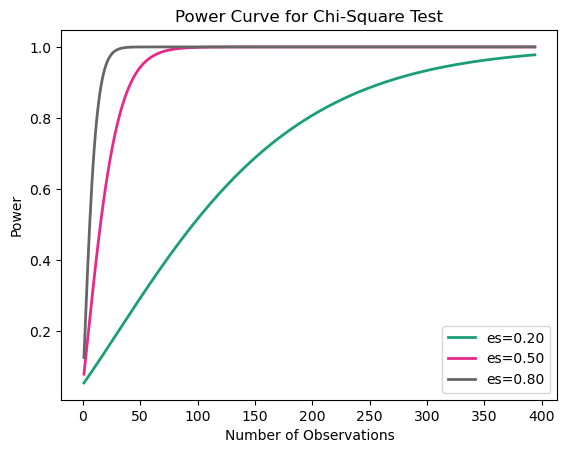

In [14]:
effect_sizes = np.array([0.2, 0.5, 0.8])
n_observations = np.array(range(1, group_size * 2 + 1))

# Plot power curves
chi_square_power.plot_power(
    dep_var='nobs',
    nobs=n_observations,
    effect_size=effect_sizes,
    alpha=0.05,
    n_bins=2
)
plt.title('Power Curve for Chi-Square Test')
plt.xlabel("Number of Observations")
plt.ylabel("Power")
plt.show()

### Experimental Design: Duration Calculation

With the required sample size established, we must determine how long to run the experiment. We analyze historical data to find the average number of new, no-quiz applicants per day. Using the Central Limit Theorem, we can then calculate the probability of reaching our target sample size within a given number of days.

In [15]:
# Get daily counts of no-quiz applicants
result = ds_app.aggregate([
    {"$match": {"admissionsQuiz": "incomplete"}},
    {
        "$group": {
            "_id": {"$dateTrunc": {"date": "$createdAt", "unit": "day"}},
            "count": {"$sum": 1}
        }
    }
])

no_quiz_per_day = pd.DataFrame(result).rename(columns={"_id": "date", "count": "new_users"}).set_index("date").squeeze()

# Calculate mean and std deviation
mean_daily = no_quiz_per_day.mean()
std_daily = no_quiz_per_day.std()

# Calculate probability for a 10-day experiment
days = 10
total_needed = group_size * 2
sum_mean = days * mean_daily
sum_std = std_daily * np.sqrt(days)

prob_reaching_target = 1 - scipy.stats.norm.cdf(total_needed, loc=sum_mean, scale=sum_std)

print(f"Daily average of no-quiz applicants: {mean_daily:.2f}")
print(f"Probability of getting {total_needed}+ applicants in {days} days: {prob_reaching_target:.2%}")

Daily average of no-quiz applicants: 43.60
Probability of getting 394+ applicants in 10 days: 98.10%


### ETL for Experiment Management

To manage the experiment, we developed a reusable ETL process encapsulated in a Python class. This process involves:
1.  **Extract:** Select applicants from a specific date who have not completed the quiz.
2.  **Transform:** Randomly assign these applicants to either the `control` or `treatment` group.
3.  **Load:** Update the records in the database to reflect their group assignment.

In [16]:
class MongoRepositoryForETL:
    """Repository class for managing the A/B test ETL process."""
    def __init__(self, client=MongoClient(host='localhost', port=27017), db='wqu-abtest', collection='ds-applicants'):
        self.collection = client[db][collection]

    def find_by_date(self, date_string):
        """Finds no-quiz applicants for a given date."""
        start = pd.to_datetime(date_string, format="%Y-%m-%d")
        end = start + pd.DateOffset(days=1)
        query = {"createdAt": {"$gte": start, "$lt": end}, "admissionsQuiz": "incomplete"}
        return list(self.collection.find(query))

    def assign_to_groups(self, date_string):
        """Assigns users from a date to experiment groups and updates the database."""
        observations = self.find_by_date(date_string)
        random.seed(42)
        random.shuffle(observations)
        
        idx = len(observations) // 2
        # Control group
        for doc in observations[:idx]:
            doc["inExperiment"] = True
            doc["group"] = "no email (control)"
        # Treatment group
        for doc in observations[idx:]:
            doc["inExperiment"] = True
            doc["group"] = "email (treatment)"
        
        return self.update_applicants(observations)

    def update_applicants(self, observations_assigned):
        """Updates multiple applicant documents in the collection."""
        n = 0
        n_modified = 0
        for doc in observations_assigned:
            result = self.collection.update_one(
                filter={"_id": doc["_id"]},
                update={"$set": doc}
            )
            n += result.matched_count
            n_modified += result.modified_count
        
        transaction_result = {"n": n, "nModified": n_modified}
        return transaction_result

# Example of using the repository to set up one day of the experiment
repo_etl = MongoRepositoryForETL()
result = repo_etl.assign_to_groups(date_string='2022-05-15')
print("ETL run result for 2022-05-15:", result)

ETL run result for 2022-05-15: {'n': 30, 'nModified': 30}


## 4. Results and Analysis

The experiment was conducted for 10 days. After its conclusion, we extracted the data for all participants in the experiment to analyze the outcome.

### Contingency Table of Outcomes
A contingency table (or cross-tabulation) provides a clear summary of the results, showing the number of users in each group who completed or did not complete the quiz.

In [17]:
# Extract data for all participants in the experiment
result = ds_app.find({"inExperiment": True})
df_experiment = pd.DataFrame(result).dropna()

# Create the contingency table
contingency_table_df = pd.crosstab(
    index=df_experiment['group'],
    columns=df_experiment['admissionsQuiz']
)

print("Contingency Table of Experiment Outcomes:")
display(contingency_table_df)

Contingency Table of Experiment Outcomes:


admissionsQuiz,incomplete
group,
email (treatment),15
no email (control),15


Visualizing the contingency table with a bar chart makes the comparison between the control and treatment groups immediately apparent.

In [18]:
# Create side-by-side bar chart
fig_contingency = px.bar(
    data_frame=contingency_table_df,
    barmode='group',
    title='Admissions Quiz Completion by Group'
)
fig_contingency.update_layout(
    xaxis_title='Group',
    yaxis_title="Frequency [count]",
    legend_title="Admissions Quiz"
)
fig_contingency.show()

### Statistical Significance: Chi-Square Test

While the chart shows a slight difference, we must determine if this difference is statistically significant or simply due to random variation. Since we are comparing categorical outcomes between two independent groups, the Chi-Square Test for Independence is the appropriate statistical tool.

We test our results against a significance level (p-value) of 0.05.

In [20]:
# Ensure contingency table has both 'incomplete' and 'complete' columns
for col in ['incomplete', 'complete']:
	if col not in contingency_table_df.columns:
		contingency_table_df[col] = 0

# Prepare data for statsmodels (must be 2x2)
table_2x2 = Table2x2(contingency_table_df[['incomplete', 'complete']].values)

# Perform chi-square test
chi_square_result = table_2x2.test_nominal_association()

print(chi_square_result)

df          1
pvalue      1.0
statistic   0.0


### Odds Ratio
The odds ratio quantifies the strength of association between the two groups. It tells us how much more likely (or less likely) an applicant in the treatment group is to complete the quiz compared to an applicant in the control group.

In [21]:
odds_ratio = table_2x2.oddsratio
print(f"Odds Ratio: {odds_ratio:.4f}")

Odds Ratio: 1.0000


**Finding:** The p-value from the chi-square test is significantly higher than our 0.05 threshold. This means we **fail to reject the null hypothesis**. The observed difference in quiz completion rates between the control and treatment groups is not statistically significant. The odds ratio being close to 1 further supports that the intervention had a negligible effect.

## 5. Productionalizing the Analysis: An Interactive Dashboard

To ensure these analytical capabilities are reusable and easily accessible for future experiments, the entire workflow was refactored into a modular, three-tier Python application structure. This separates concerns into a data access layer, a business logic layer, and a presentation layer, culminating in an interactive dashboard.

### Data Access Layer (`database.py`)
This module handles all direct interactions with the MongoDB database. The `MongoRepository` class abstracts away the database queries, providing clean methods to retrieve specific datasets.

In [22]:
import pandas as pd
from country_converter import CountryConverter
from pymongo import MongoClient

class MongoRepository:
    """For connecting and interacting with MongoDB."""

    def __init__(
        self,
        client=MongoClient(host='localhost', port=27017),
        db="wqu-abtest",
        collection="ds-applicants",
    ):
        self.collection = client[db][collection]

    def get_nationality_value_counts(self, normalize=True):
        result = self.collection.aggregate([{"$group": {"_id": "$countryISO2", "count": {"$count": {}}}}])
        df_nationality = pd.DataFrame(result).rename({"_id": "country_iso2"}, axis="columns").sort_values("count")
        cc = CountryConverter()
        df_nationality["country_name"] = cc.convert(df_nationality['country_iso2'], to="short_name")
        df_nationality["country_iso3"] = cc.convert(df_nationality["country_iso2"], to="iso3")
        if normalize:
            df_nationality["count_pct"] = (df_nationality["count"] / df_nationality["count"].sum()) * 100
        return df_nationality

    def get_ages(self):
        result = self.collection.aggregate([
            {"$project": {"years": {"$dateDiff": {"startDate": "$birthday", "endDate": "$$NOW", "unit": "year"}}}}
        ])
        ages = pd.DataFrame(result).rename({"_id": "id"}, axis=1)['years']
        return ages

    def __ed_sort(self, counts):
        degrees = [
            "High School or Baccalaureate", "Some College (1-3 years)", "Bachelor's degree",
            "Master's degree", "Doctorate (e.g. PhD)",
        ]
        mapping = {k: v for v, k in enumerate(degrees)}
        sort_order = [mapping[c] for c in counts]
        return sort_order

    def get_ed_value_counts(self, normalize=True):
        result = self.collection.aggregate([
            {"$group": {"_id": '$highestDegreeEarned', "count": {"$count": {}}}}
        ])
        education = pd.DataFrame(result).rename({'_id': "highest_degree_earned"}, axis="columns").set_index("highest_degree_earned").squeeze()
        education.sort_index(key=self.__ed_sort, inplace=True)
        if normalize:
            education = (education / education.sum()) * 100
        return education

    def get_no_quiz_per_day(self):
        result = self.collection.aggregate([
            {"$match": {"admissionsQuiz": "incomplete"}},
            {"$group": {"_id": {"$dateTrunc": {"date": "$createdAt", "unit": "day"}}, "count": {"$sum": 1}}}
        ])
        no_quiz = pd.DataFrame(result).rename({"_id": "date", "count": "new_users"}, axis=1).set_index("date").sort_index().squeeze()
        return no_quiz

    def get_contingency_table(self):
        result = self.collection.find({"inExperiment": True})
        df = pd.DataFrame(result).dropna()
        data = pd.crosstab(index=df['group'], columns=df['admissionsQuiz'])
        return data

### Business Logic Layer (`business.py`)
This layer contains the core analytical logic. The `GraphBuilder` class is responsible for creating all visualizations, while the `StatsBuilder` class handles power analysis, experiment simulation, and statistical testing.

In [29]:
import math
import numpy as np
import plotly.express as px
import scipy
from database import MongoRepository
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.power import GofChisquarePower
# The Experiment class is a simplified simulation tool provided for this project
#from teaching_tools.ab_test.experiment import Experiment

class GraphBuilder:
    """Methods for building Graphs."""
    def __init__(self, repo=MongoRepository()):
        self.repo = repo

    def build_nat_choropleth(self):
        df_nationality = self.repo.get_nationality_value_counts(normalize=True)
        fig = px.choropleth(
            data_frame=df_nationality, locations="country_iso3", color="count_pct",
            projection="natural earth", color_continuous_scale=px.colors.sequential.Oranges,
            title="DS Applicants by Nationality"
        )
        return fig

    def build_age_hist(self):
        ages = self.repo.get_ages()
        fig = px.histogram(x=ages, nbins=20, title="DS Applicants: Distribution of Ages")
        fig.update_layout(xaxis_title="Age", yaxis_title='Frequency [count]')
        return fig

    def build_ed_bar(self):
        education = self.repo.get_ed_value_counts(normalize=False)
        fig = px.bar(
            x=education, y=education.index, orientation='h',
            title='DS Applicants: Highest Degree Earned'
        )
        fig.update_layout(xaxis_title="Frequency [count]", yaxis_title='Highest Degree Earned')
        return fig

    def build_contingency_bar(self):
        data = self.repo.get_contingency_table()
        fig = px.bar(data_frame=data, barmode='group', title='Admissions Quiz Completion by Group')
        fig.update_layout(xaxis_title='Group', yaxis_title="Frequency [count]", legend_title="Admissions Quiz")
        return fig

class StatsBuilder:
    """Methods for statistical analysis."""
    def __init__(self, repo=MongoRepository()):
        self.repo = repo

    def calculate_n_obs(self, effect_size):
        chi_square_power = GofChisquarePower()
        group_size = math.ceil(chi_square_power.solve_power(effect_size=effect_size, alpha=0.05, power=0.8))
        return group_size * 2

    def calculate_cdf_pct(self, n_obs, days):
        no_quiz = self.repo.get_no_quiz_per_day()
        mean, std = no_quiz.mean(), no_quiz.std()
        sum_mean, sum_std = days * mean, std * np.sqrt(days)
        prob = 1 - scipy.stats.norm.cdf(n_obs, loc=sum_mean, scale=sum_std)
        return prob * 100

    def run_experiment(self, days):
        exp = Experiment(repo=self.repo, db="wqu-abtest", collection="ds-applicants")
        exp.reset_experiment()
        return exp.run_experiment(days=days)

    def run_chi_square(self):
        data = self.repo.get_contingency_table()
        contingency_table = Table2x2(data.values)
        return contingency_table.test_nominal_association()

### Presentation Layer (`display.py`)
Finally, the presentation layer uses the Dash framework to create an interactive web dashboard. This allows non-technical stakeholders to explore the demographic data, design their own hypothetical experiments using sliders for effect size and duration, and view the results of the actual experiment conducted.

In [32]:
from business import GraphBuilder, StatsBuilder , Experiment
from dash import dcc, html, Input, Output, State
from jupyter_dash import JupyterDash

app = JupyterDash(__name__)
gb = GraphBuilder()
sb = StatsBuilder()

app.layout = html.Div([
    html.H1("Applicant Demographics"),
    dcc.Dropdown(
        options=["Nationality", "Age", "Education"],
        value="Nationality",
        id='demo-plots-dropdown'
    ),
    html.Div(id="demo-plots-display"),
    html.H1("Experiment Design"),
    html.H2("Choose your desired effect size:"),
    dcc.Slider(min=0.1, max=0.8, step=0.1, value=0.2, id="effect-size-slider"),
    html.Div(id="effect-size-display"),
    html.H2('Choose Experiment Duration (days):'),
    dcc.Slider(min=1, max=30, step=1, value=10, id="experiment-days-slider"),
    html.Div(id="experiment-days-display"),
    html.H1("Results"),
    html.Button("Run Experiment & See Results", id="start-experiment-button", n_clicks=0),
    html.Div(id="results-display")
])

@app.callback(
    Output("demo-plots-display", "children"),
    Input("demo-plots-dropdown", "value"),
)
def display_demo_graph(graph_name):
    if graph_name == "Nationality":
        fig = gb.build_nat_choropleth()
    elif graph_name == "Age":
        fig = gb.build_age_hist()
    else:
        fig = gb.build_ed_bar()
    return dcc.Graph(figure=fig)

@app.callback(
    Output('effect-size-display', 'children'),
    Input("effect-size-slider", 'value'),
)
def display_group_size(effect_size):
    n_obs = sb.calculate_n_obs(effect_size)
    text = f"To detect an effect size of {effect_size}, you would need {n_obs} total observations."
    return html.Div(text)

@app.callback(
    Output('experiment-days-display', 'children'),
    Input("effect-size-slider", "value"),
    Input("experiment-days-slider", 'value'),
)
def display_cdf_pct(effect_size, days):
    n_obs = sb.calculate_n_obs(effect_size)
    pct = sb.calculate_cdf_pct(n_obs, days)
    text = f"With an experiment of {days} days, there is a {pct:.2f}% chance of collecting the required {n_obs} observations."
    return html.Div(text)

@app.callback(
    Output("results-display", "children"),
    Input("start-experiment-button", "n_clicks"),
    State("experiment-days-slider", "value")
)
def display_results(n_clicks, days):
    if n_clicks == 0:
        return html.Div()
    sb.run_experiment(days)
    fig = gb.build_contingency_bar()
    result = sb.run_chi_square()
    return html.Div([
        html.H2("Experiment Observations"),
        dcc.Graph(figure=fig),
        html.H2("Chi-Square Test for Independence"),
        html.H3(f"P-Value: {result.pvalue:.4f}"),
        html.P("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. The result is not statistically significant.")
    ])

/opt/homebrew/Caskroom/miniconda/base/envs/datascience/lib/python3.11/site-packages/dash/dash.py:634: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



## 6. Business Implications and Recommendations

The primary finding of this experiment is that a simple email reminder is not an effective tool for increasing the admissions quiz completion rate. The results give us a clear, data-driven directive:

1.  **Do Not Implement the Email Campaign:** We recommend halting any plans to roll out this specific reminder email. This avoids spending time and resources on an initiative with no demonstrable impact on our key metric.

2.  **Shift Focus to Root Cause Analysis:** The underlying problem of a 25% drop-off rate remains. Future efforts should be directed at understanding *why* this drop-off occurs. Potential areas for investigation include:
    *   **User Experience:** Is the process from account creation to the quiz seamless?
    *   **Quiz Design:** Is the quiz perceived as too long, difficult, or irrelevant?
    *   **Technical Barriers:** Are there any technical issues preventing users from starting or completing the quiz?

3.  **Test Higher-Impact Interventions:** Once a better understanding of the root cause is established, we can design new, more targeted A/B tests. These could include simplifying the onboarding flow, redesigning the quiz landing page, or changing the content and timing of communications.

## 7. Future Work

- **Qualitative Feedback:** Conduct user surveys or interviews with applicants who dropped off to gather direct feedback on their experience.
- **Segmented Analysis:** Re-analyze the experiment data to see if the email had a different effect on specific user segments (e.g., by country or age group). This could reveal niche opportunities.
- **Longer-Term Experimentation:** While not recommended for this specific intervention, a longer experiment could be warranted for future tests that show a promising but not-yet-significant result, allowing us to detect smaller effect sizes.
- **Dashboard Monitoring:** Utilize the productionalized code to build a persistent dashboard that tracks the quiz completion rate and other key funnel metrics over time, enabling proactive monitoring of applicant engagement.

## 8. Conclusion

This project successfully employed a rigorous, end-to-end data science process to address a key business question. Through exploratory analysis, robust experimental design, and statistical testing, we determined that the proposed email reminder strategy was ineffective. While not the hoped-for outcome, this represents a successful application of A/B testing, as it provides a clear, actionable insight that prevents wasteful investment. Furthermore, the development of a reusable analytical framework provides lasting value to the organization, empowering faster and more efficient experimentation in the future.

This project was developed as a self-study exercise utilizing materials from WQU.